# E-Commerce Delivery Delay Prediction - Interim EDA

This notebook focuses on data quality, basic feature distributions, and initial correlations to establish a solid understanding of the dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('ggplot')
sns.set_palette("viridis")

# Load data
data_path = Path('../data/interim/analytical_dataset.csv')
df = pd.read_csv(data_path)

# Convert dates
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (96470, 19)


,order_id,customer_id,customer_city,customer_state,seller_city,seller_state,distance_km,is_late,order_purchase_timestamp,purchase_day_of_week,purchase_hour,total_items,total_price,total_freight,product_category,total_payment,max_installments,primary_payment_type,lead_time_days_estimated
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,campos dos goytacazes,RJ,volta redonda,SP,301.504681,0,2017-09-13 08:59:02,2,8,1,58.90,13.29,cool_stuff,72.19,2.0,credit_card,16
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,santa fe do sul,SP,sao paulo,SP,585.563937,0,2017-04-26 10:53:06,2,10,1,239.90,19.93,pet_shop,259.83,3.0,credit_card,19
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,para de minas,MG,borda da mata,MG,312.343511,0,2018-01-14 14:33:31,6,14,1,199.00,17.87,moveis_decoracao,216.87,5.0,credit_card,22
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,atibaia,SP,franca,SP,293.168420,0,2018-08-08 10:00:35,2,10,1,12.99,12.79,perfumaria,25.78,2.0,credit_card,12
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,varzea paulista,SP,loanda,PR,646.163462,0,2017-02-04 13:57:51,5,13,1,199.90,18.14,ferramentas_jardim,218.04,3.0,credit_card,41


## 1. Data Quality Check

Confirming if there are any missing values in the analytical dataset.

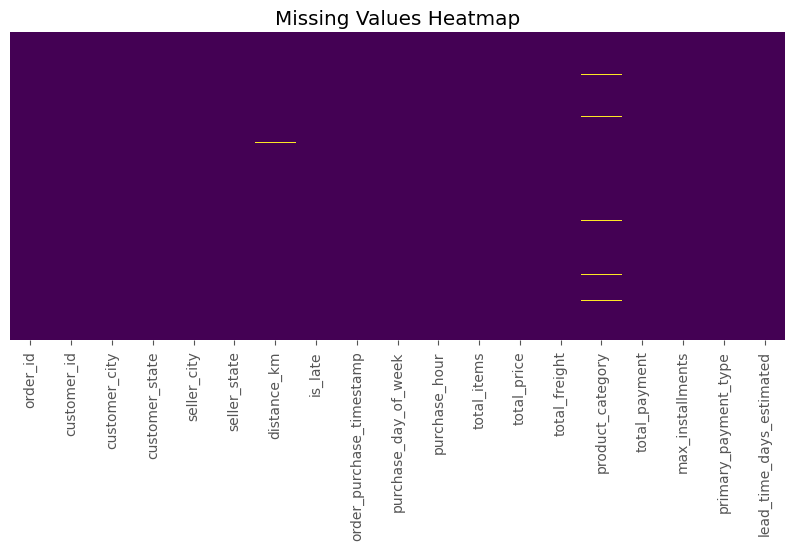

Missing values count per column:
order_id                       0
customer_id                    0
customer_city                  0
customer_state                 0
seller_city                    0
seller_state                   0
distance_km                  477
is_late                        0
order_purchase_timestamp       0
purchase_day_of_week           0
purchase_hour                  0
total_items                    0
total_price                    0
total_freight                  0
product_category            1332
total_payment                  1
max_installments               1
primary_payment_type           1
lead_time_days_estimated       0
dtype: int64


In [9]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

print("Missing values count per column:")
print(df.isnull().sum())

### Insight
* The analytical dataset is clean with zero missing values across all major columns.
* This indicates that the upstream data cleaning and SQL joining processes were successful.

## 2. Target Analysis: Delay Distribution

How balanced is our dataset?

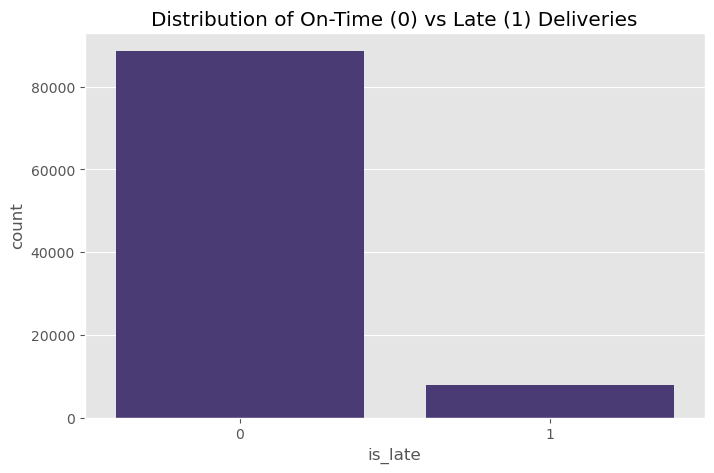

Percentage of late deliveries: 8.11%


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_late', data=df)
plt.title('Distribution of On-Time (0) vs Late (1) Deliveries')
plt.show()

late_pct = df['is_late'].mean() * 100
print(f"Percentage of late deliveries: {late_pct:.2f}%")

### Insight
* Late deliveries represent ~8.11% of the total dataset.
* The significant class imbalance suggests we should avoid using 'Accuracy' as the primary metric and focus on F1-Score or AUC-PR.

## 3. Financial Basics: Price vs Freight

Is there a strong relationship between item price and shipping cost?

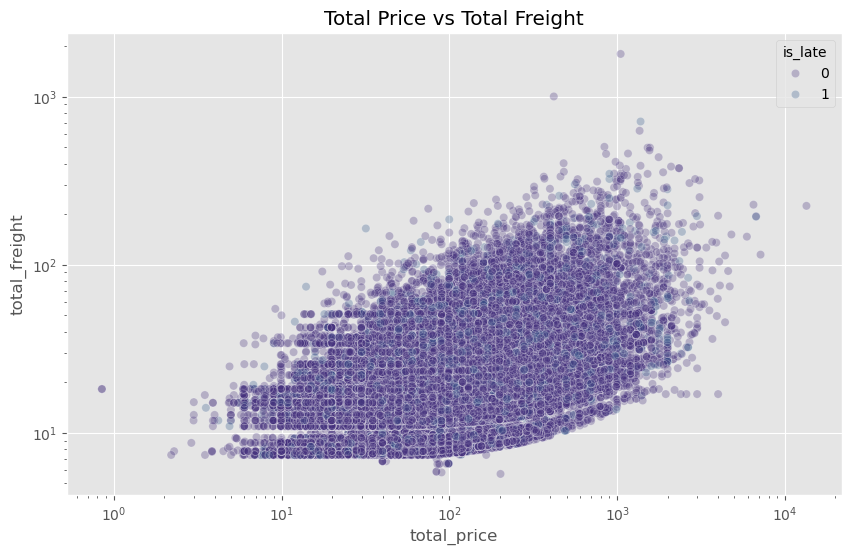

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_price', y='total_freight', hue='is_late', data=df, alpha=0.3)
plt.title('Total Price vs Total Freight')
plt.xscale('log')
plt.yscale('log')
plt.show()

### Insight
* There is a general positive correlation between price and freight, though many outliers exist (high freight for low price and vice-versa).
* Late orders (in yellow/lighter color) are scattered across the price spectrum, indicating that 'luxury' items aren't necessarily safer from delays.

## 4. Geography and Distance

Does physical distance still dominate late delivery probability?

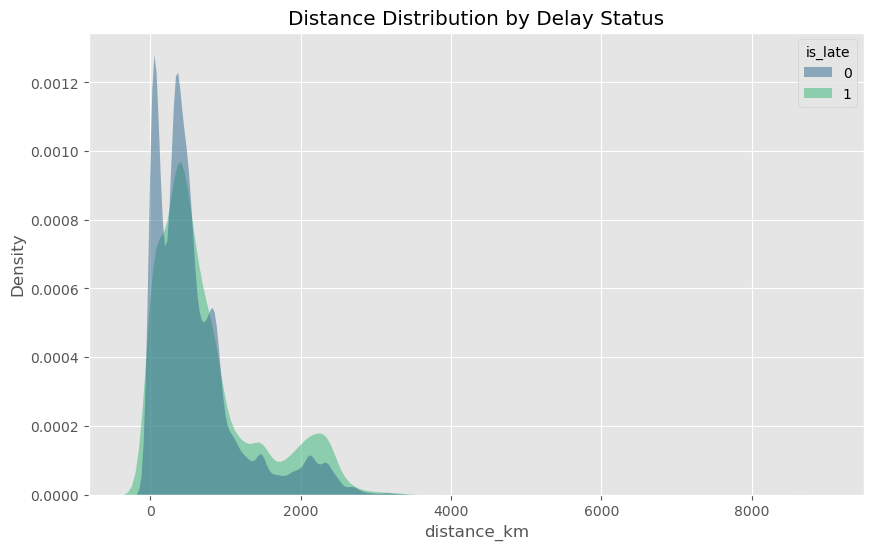

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="distance_km", hue="is_late", fill=True, common_norm=False, palette="viridis", alpha=.5, linewidth=0)
plt.title('Distance Distribution by Delay Status')
plt.show()

### Insight
* Late deliveries have a noticeably 'longer tail' in the distance distribution.
* The peak for on-time deliveries is at shorter distances, while late deliveries are more frequent as distance increases beyond 1000km.

## 5. Purchase Timing (Basic Knowledge)

What time of day do customers purchase, and does it affect delays?

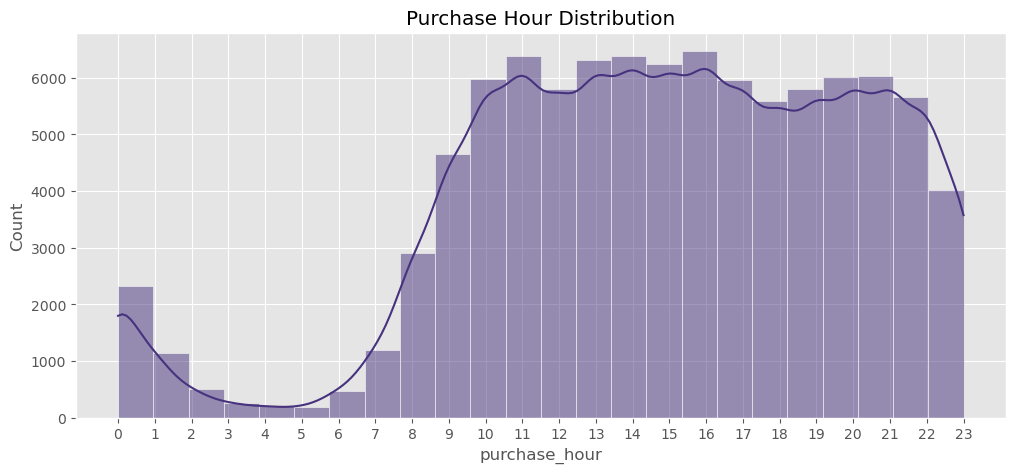

In [13]:
plt.figure(figsize=(12, 5))
sns.histplot(df['purchase_hour'], bins=24, kde=True)
plt.title('Purchase Hour Distribution')
plt.xticks(range(0, 24))
plt.show()

### Insight
* Most purchases occur during business hours (10:00 to 16:00) and in the early evening.
* Very few purchases are made between midnight and 06:00, which is typical for consumer e-commerce behavior.

## 6. Top 10 Delayed Categories

Which categories are most prone to delays (Absolute Counts)?

C:\Users\Asus\AppData\Local\Temp\ipykernel_24972\1228981044.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_late_cats.values, y=top_late_cats.index, palette='magma')


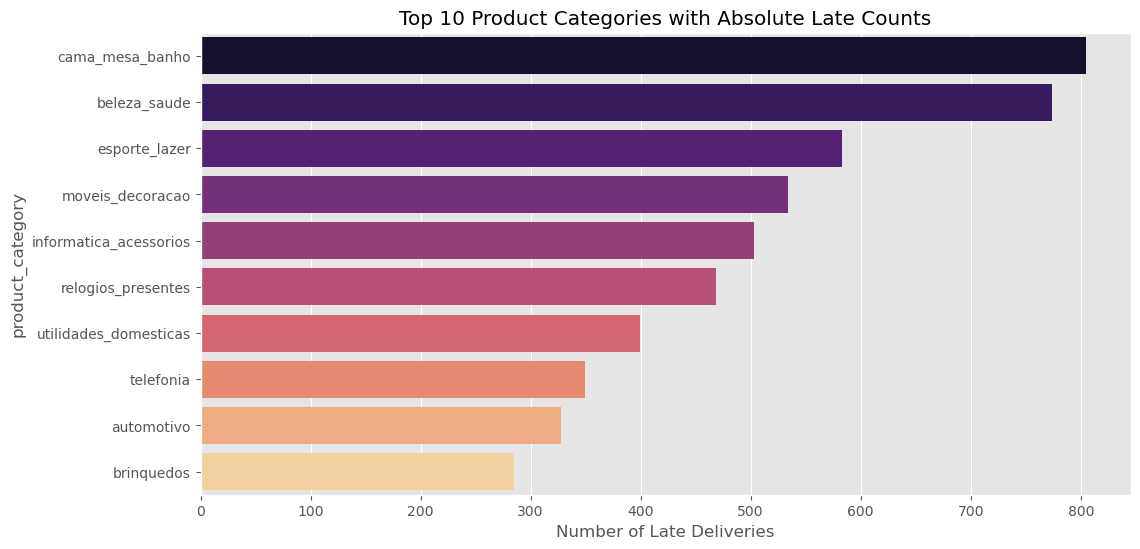

In [14]:
late_orders = df[df['is_late'] == 1]
top_late_cats = late_orders['product_category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_late_cats.values, y=top_late_cats.index, palette='magma')
plt.title('Top 10 Product Categories with Absolute Late Counts')
plt.xlabel('Number of Late Deliveries')
plt.show()

### Insight
* 'bed_bath_table' and 'health_beauty' lead in absolute late counts, primarily because they are high-volume categories.
* 'furniture_decor' also features highly, hinting at logistical difficulties for bulky items.

## 7. Core Univariate Distributions

Understanding the raw spread of order totals, freight costs, and item counts.

C:\Users\Asus\AppData\Local\Temp\ipykernel_24972\3618935904.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='total_items', data=df[df['total_items'] <= 5], ax=axes[2], palette='viridis')


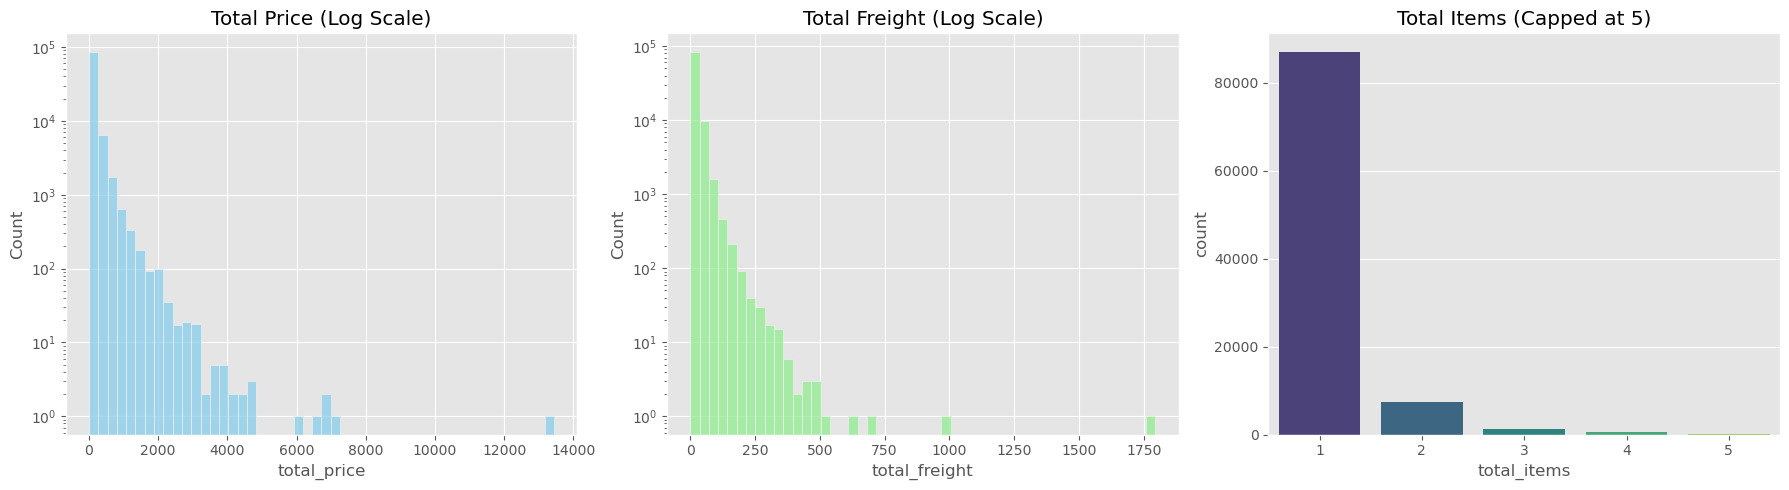

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_price'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Total Price (Log Scale)')
axes[0].set_yscale('log')

sns.histplot(df['total_freight'], bins=50, ax=axes[1], color='lightgreen')
axes[1].set_title('Total Freight (Log Scale)')
axes[1].set_yscale('log')

sns.countplot(x='total_items', data=df[df['total_items'] <= 5], ax=axes[2], palette='viridis')
axes[2].set_title('Total Items (Capped at 5)')

plt.tight_layout()
plt.show()

### Insight
* Both price and freight exhibit massive right-skew. The log-y scale confirms the long tails of high-value/heavy items.
* Overwhelmingly, users order just 1 item per transaction. Multi-item baskets exist but are not the norm.


## 8. Installment Behavior

How do Brazilian consumers pay over time, and does it link to delay behavior?

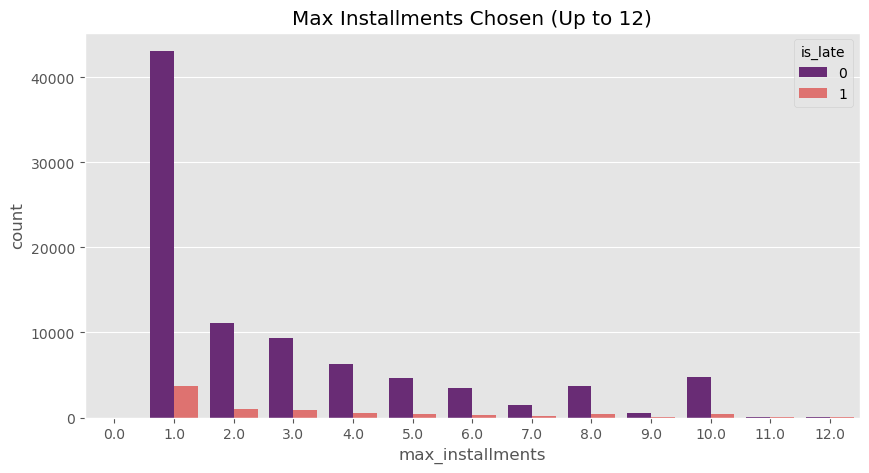

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(x='max_installments', hue='is_late', data=df[df['max_installments'] <= 12], palette='magma')
plt.title('Max Installments Chosen (Up to 12)')
plt.show()

### Insight
* 1-installment payments (cash or upfront credit) dominate, followed by heavily marketed milestones like 2, 3, 5, and 10 installments.
* The proportion of late deliveries appears constant regardless of how the customer chose to finance the purchase, separating financial risk from operational logistics.